# BDA (mean-centred PLS)

Barycentric discriminant analysis (BDA; [Abdi and Williams, 2018](https://doi.org/10.1007/978-1-4614-7163-9_110192-2)), also known as mean-centred partial least squares (mean-centred PLS; [Krishnan et al., 2011](https://doi.org/10.1016/j.neuroimage.2010.07.034)) is a tool for identifying multivariate patterns that differentiate between multiple conditions. The basic idea is to perform singular value decomposition on a matrix of condition-wise averages (barycentres) whose columns have been mean-centred.

## Setting up simulated data

We will simulate a dataset with a between-participants condition and a within-participants condition. There will be a main effect of between-participants condition, a main effect of within-participants condition, and an interaction (all orthogonal to each other). The pattern of the between-participants main effect will be linear over the observed variables and the pattern of both the within-participants main effect and the interaction will be sinusoidal over the observed variables

In [60]:
import numpy as np
import pandas as pd
from pyplsc import BDA
from matplotlib import pyplot as plt

np.random.seed(123)

n_var = 50
n_subj = 30
data = 0.5*np.random.normal(size=(n_subj*2, n_var))
design = pd.DataFrame({
    'group': ['g-a']*n_subj + ['g-b']*n_subj,
    'cond': ['c-a', 'c-b']*n_subj,
    'subj': np.cumsum([1, 0]*n_subj)
})
between_effect = np.arange(n_var)/n_var - 0.5 # Linear pattern over observed variables
within_effect = np.sin(0.2*np.arange(n_var)) # Sinusoidal pattern over observed variables
interaction = np.cos(0.2*np.arange(n_var)) # Ditto
data[design['group'] == 'g-b'] += between_effect
data[design['cond'] == 'c-b'] += within_effect
data[(design['group'] == 'g-b') & (design['cond'] == 'c-b')] += interaction
data[(design['group'] == 'g-a') & (design['cond'] == 'c-a')] += interaction
data[(design['group'] == 'g-a') & (design['cond'] == 'c-b')] -= interaction
data[(design['group'] == 'g-b') & (design['cond'] == 'c-a')] -= interaction

We can visualize each of these patterns as follows:

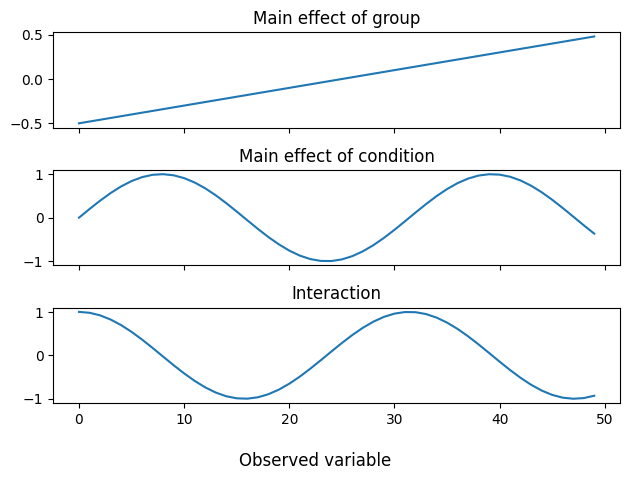

In [61]:
f, ax = plt.subplots(3, 1, sharex=True)
ax[0].plot(between_effect)
ax[0].set_title('Main effect of group')
ax[1].plot(within_effect)
ax[1].set_title('Main effect of condition')
ax[2].plot(interaction)
ax[2].set_title('Interaction')
f.supxlabel('Observed variable')
plt.tight_layout()
plt.show()

## Fitting and evaluating model

Next, we can fit the BDA model to this data. We'll provide the design matrix and specify which columns correspond to the between- and within-participants factors, as well as which column differentiates participants (which is necessary when there is a within-participants factor):

In [62]:
mod = BDA(random_state=123)
mod.fit(data,
        design,
        between='group',
        within='cond',
        participant='subj')

We can assess the significance of each latent variable using permutation testing as follows:

In [63]:
mod.permute(1000)
print(mod.pvals_)
is_sig = mod.pvals_ < 0.05
sig_lvs = np.where(is_sig)[0]
print(sig_lvs)

Permuting: 100%|█████████████████████████████████████████████████████████████████| 1000/1000 [00:00<00:00, 1432.61it/s]

[0.000999 0.000999 0.000999      nan]
[0 1 2]


There are 3 significant latent variables (one for each effect we simulated). Note that mean-centering reduces the rank of the decomposed matrix by 1, such that the final singular value is always 0 and the final $p$ value is not meaningful. Next, we can perform bootstrap resampling to assess the reliability of the data saliences and to evaluate how reliably each latent variable is differentially expressed in each condition. Afterward, we will see how to visualize the results of this resampling.

In [64]:
mod.bootstrap(1000, return_boot_stat_dist=False)

Resampling: 100%|█████████████████████████████████████████████████████████████████| 1000/1000 [00:01<00:00, 782.56it/s]


## Visualizing the model

Bootstrap resampling yields two things: first, it estimates the standard deviation of the data saliences and thus allows us to estimate a z score or "bootstrap ratio" for each salience. Second, it allows us to estimate the variability of the average scores in each condition. These values are available in the `data_sals_z_` and `boot_stat_ci_` attributes, respectively. For plotting `boot_stat_ci_` in a `matplotlib` bar plot, the `get_boot_stat_yerr` method is useful:

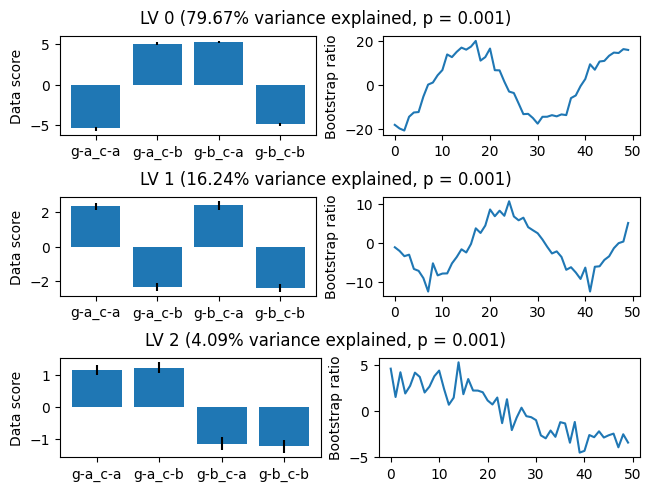

In [66]:
labels = mod.design_sal_labels_
labels = labels['between'].astype(str) + '_' + labels['within'].astype(str)
n_sig = len(sig_lvs)
n_sig = 3 # For debugging

fig = plt.figure(constrained_layout=True)
subfigs = fig.subfigures(nrows=n_sig)

for lv_idx in range(n_sig):
    subfig = subfigs[lv_idx]
    subfig.suptitle('LV %s (%.2f%% variance explained, p = %.3f)' % (
        lv_idx,
        100*mod.variance_explained_[lv_idx],
        mod.pvals_[lv_idx]))
    ax = subfig.subplots(ncols=2)
    ax[0].bar(x=labels,
                      height=mod.boot_stat_val_[:, lv_idx],
                      yerr=mod.get_boot_stat_yerr(lv_idx))
    ax[0].set_ylabel('Data score')
    ax[1].plot(mod.data_sals_z_[:, lv_idx])
    ax[1].set_ylabel('Bootstrap ratio')

As we can see, the model approximately identifies both patterns and their differential expression as a function of between-participants group and within-participants condition.

## Main effects and interactions

When there are both within- and between-participants conditions, it is possible to selectively examine any combination of the main effects and the interaction. In the original Matlab PLS, the defualt behaviour (controlled in `plscmd` by `cfg.meancentering_mode = 0`) when there are both within- and between-participants conditions is to subtract any between-participants main effect in the mean-centering step, thereby examining only the within-participants main effect and the interaction. Matlab PLS also gives the option to subtract the within-participants main effect (`cfg.meancentering_mode = 0`) and to subtract both the within- and between-participants main effects, and thereby evaluate only the interaction (`cfg.meancentering_mode = 3`).

In `pyplsc`, the effects modeled can be specified by the `effects` argument to `.fit()` as an iterable containing any combination of `'within'`, `'between'`, and `'interaction'`. For example, we can replicate the original default behaviour of 